<a href="https://colab.research.google.com/github/ganon-evans-capp/ds-20195-GE-final-project/blob/main/Data_and_the_State_Final_Project_GE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AirB-n-Barcelona

Microproject by Ganon Evans for Data and the State, Spring Quarter 2026

Over the last two decades, Barcelona has had waves of antitourist activism protesting increasing costs of living and housing shortages. Using data from the City of Barcelona and AirBnB, this project attempts to model the network of AirBnB owners across the city, including concentration by area and the degree to which largescale owners exist.

## Background

For the 1992 Olympics, the industrial port city of Barcelona was transformed through urban development into a multicultural city on a scenic Mediterranean beach front [1]. In the decades after, Barcelona became a tourist hotspot. The city estimated that in 2023, it received 26 million tourists compared to its resident population of just 1.5 million people [2]. From 2000 and 2015, the number of cruise passengers stopping in Barcelona quintupled, with 57% of them not even spending the night in the city [1]. Despite the increase in visitors, the residential population near the city center declined by 11% between 2015 and 2019 - that accounts for about 100,000 people [Q].

The proliferation of tourism is not without its critics, who argue that the industry does not create high-paying jobs, inflates local prices, and constrains the housing market. Madrid and Barcelona, Spain's two largest urban centers, have costs of living that are 20% higher than elsewhere in the country; yet, the adjusted purchasing power from higher wages is only 21% higher, meaning that low-income communities with stagnant wages may be forced to move if tourism drives up prices [3]. Barcelona has been identified has one of the top cities in the EU with low housing stock, and between 2013 to 2016, rental income increased by 23% [4]. 

The most cited paper I could find regarding AirBnB's in Barcelona was a 2020 piece in the Journal of Urban Economics by Garcia-López et al [5]. According to the paper, neighborhood variation in price increases due to AirBnB prescence fluctuated by neighborhood, but on average, AirBnB activity increased rents by 1.9% and posted prices by 3.7%. In the neighborhoods most occupied by rentals, rents have increased by 7% while posted prices have increased by 17%. The authors argued that a big part of the prolifertion of units is the opportunity for high profits distorting the incentives of local to sell out their properties instead of reside in them long-term.

In 2017, the left-leaning Catalan collective Arran spraypainted tour buses, slashed the tires of rental bicycles, and occupied local beaches with banners reading "For the abolition of holiday rentals."[6]. The same year, Barcelona implemented a moratorium called the Special Tourist Accommodation Plan (PEAUT) which suspended all new urban planning, licenses, and land management projects related to tourism; the plan was repealed in 2019 after protest by landlords and insufficient economic results [7]. In Summer 2025, water guns became symbols of affordable housing protestors, who targeted hostel residents and their workers [8]. As of February 2026, Barcelona has a 15 euro nightly tourist tax in place, and the parliament of Catalonia has approved a bill that would ban all holiday rentals by 2028 [9][10].

## Part 0: Data Sources and Packages

In [55]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import circlify

In [75]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlepad"] = 12

In [76]:
#quarterly AirBnB data for the last 12 months, recorded December 14th, 2025
airbnb_listings = pd.read_csv("data/listings.csv")

#a nice geojson of Barcelona's neighborhoods, also provided by AirBnB
barcelona_neighborhoods = gpd.read_file("data/neighbourhoods.geojson")

#Barcelona's property transactions data. Not geospatial, so we will have to match it to a the neighborhoods by the neighborhood name.
real_estate_df = pd.read_csv("data/2025_notaris_compravendes_trans_tip_us.csv")

BAR_EPSG = 25830 #Standard for mainland Spain


## Part 1: Property Transactions by Neighbourhood

The transaction data lists how many transactions by property type in each neighborhood. Let's narrow the property transactions to properties labeled as residential units or for tourists. These three categories make up 53% of the rows and are contrasted with things like offices and commercial spaces.

In [77]:
#Since the real_estate_df is in Catalan, I do some cleaning of the headers
real_estate_df = real_estate_df.rename(columns={"Nom_Barri": "neighbourhood", "Tipologia_Us_Desc": "property_use", "Nombre": "transaction_count"})

real_estate_df = real_estate_df.loc[real_estate_df["property_use"].isin(["Residencial", "Turístic"])]

real_estate_df["property_use"] = real_estate_df["property_use"].replace({
    "Residencial": "Residential",
    "Turístic": "Tourist"
})

#NA values were listed as "..", so I turned everything into a number and dropped the empty rows
real_estate_df["transaction_count"] = pd.to_numeric(real_estate_df["transaction_count"], errors="coerce")
real_estate_df = real_estate_df.dropna(subset=["transaction_count"])

real_estate_joined_df = barcelona_neighborhoods.merge(real_estate_df, on="neighbourhood", how="right")

neighbourhood_rs_choro = real_estate_joined_df.dissolve(by="neighbourhood", aggfunc={"transaction_count": "sum"}).reset_index()

neighbourhood_rs_choro = neighbourhood_rs_choro.to_crs(BAR_EPSG)

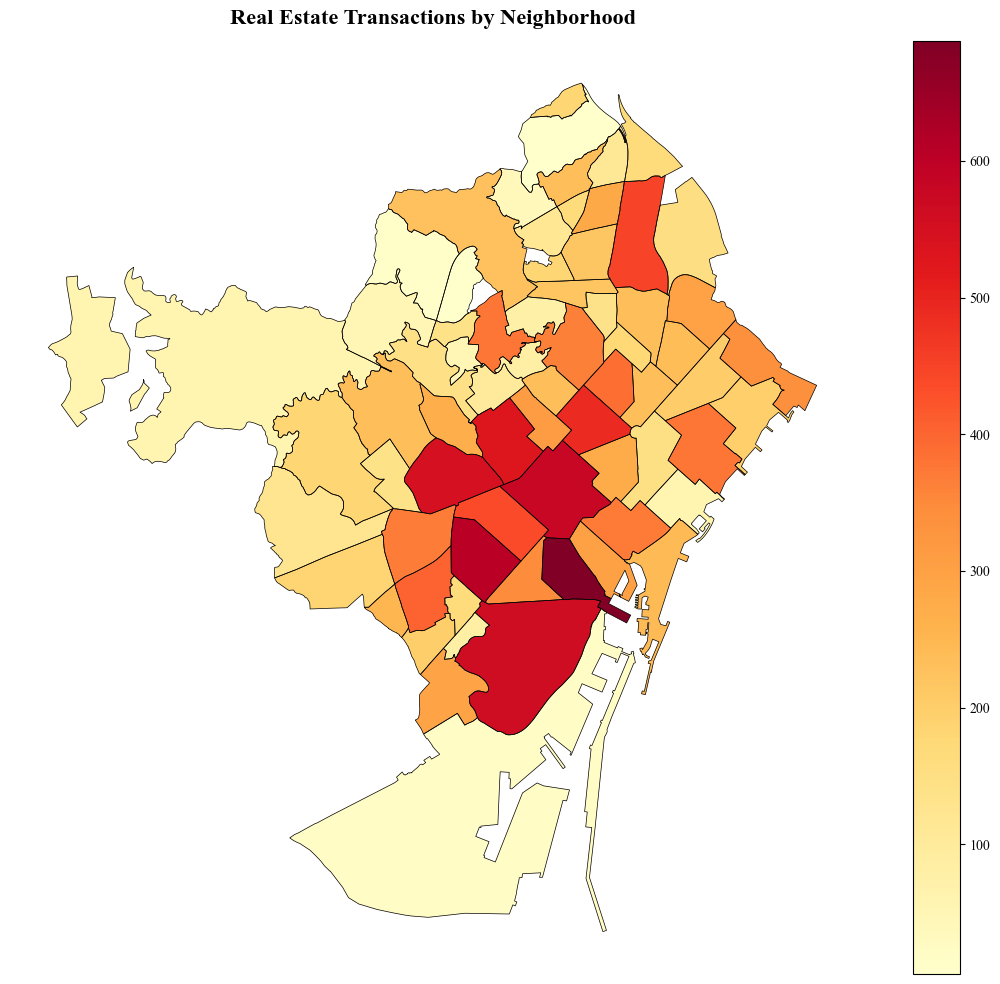

In [78]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
neighbourhood_rs_choro.plot(
    column="transaction_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
)
neighbourhood_rs_choro.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
ax.set_title("Real Estate Transactions by Neighborhood", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

Now, we can plot the location of AirBnBs relative to the neighborhoods with the most real estate transactions.

In [79]:
def to_gdf(df):
    geometry = gpd.points_from_xy(df["longitude"], df["latitude"])  # x=lon, y=lat
    return gpd.GeoDataFrame(df, geometry=geometry, crs=4326).to_crs(BAR_EPSG)

airbnb_gdf = to_gdf(airbnb_listings)

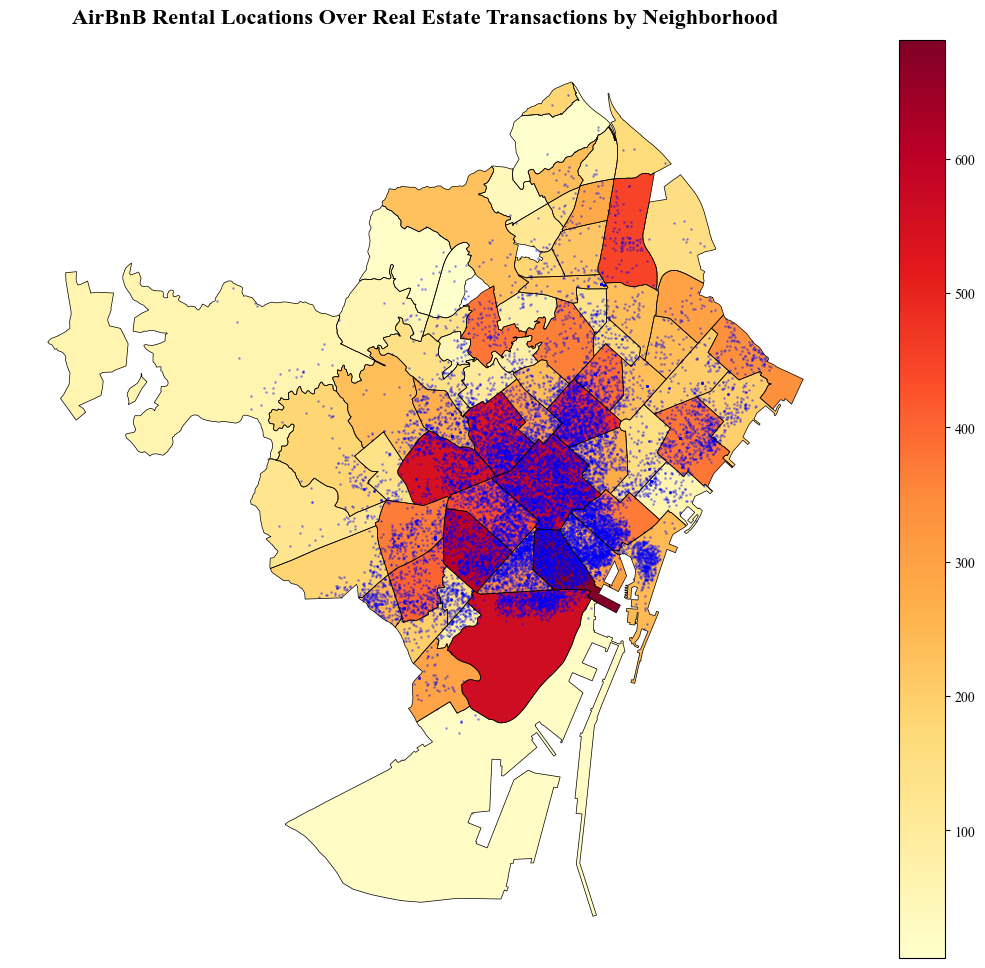

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
neighbourhood_rs_choro.plot(
    column="transaction_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
)
neighbourhood_rs_choro.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
airbnb_gdf.plot(
    ax=ax,
    color="blue",
    markersize=1,
    alpha=0.3
)
ax.set_title("AirBnB Rental Locations Over Real Estate Transactions by Neighborhood")
ax.axis("off")
plt.tight_layout()
plt.show()

Well, there's a few problems here. For one, the AirBnB data is not an exact latitude and longitude of every residence out of privacy concerns, so the points aren't exactly a one-to-one of where a unit is. Similarly, its hard to differentiate the concentration in the city center. 

Instead of plotting every AirBnB as an individual point, we can use hexbin to bin the listings into hexagonal cells and color each cell by how many listings fall inside it. This kernel-density-style view makes the concentration of rentals much easier to read. 

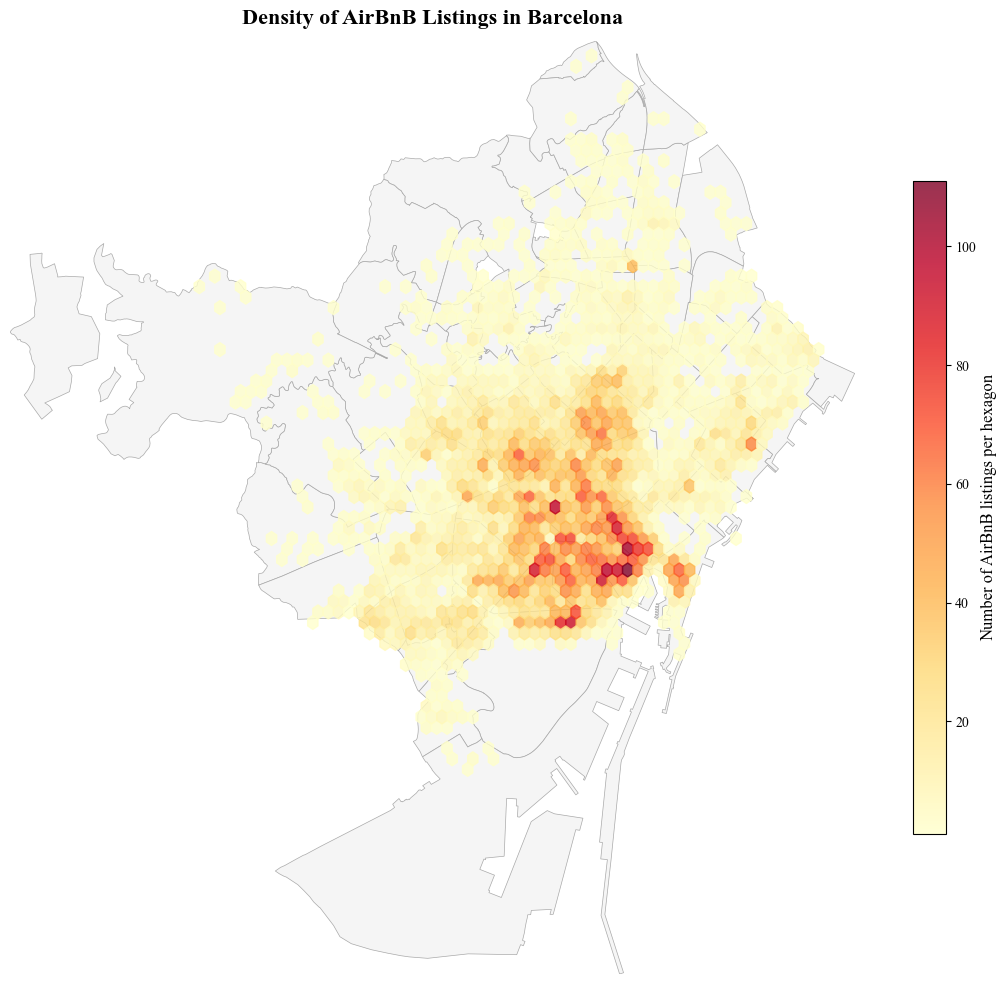

In [81]:
# Hexbin density map of AirBnB listings.
# No contextily needed — the neighbourhood polygons serve as the basemap.

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Light grey neighbourhood fill as the base layer.
neighbourhood_rs_choro.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="darkgrey",
    linewidth=0.5,
)

hb = ax.hexbin(
    airbnb_gdf.geometry.x,
    airbnb_gdf.geometry.y,
    gridsize=60,
    cmap="YlOrRd",
    mincnt=1,
    alpha=0.8,
)

cbar = fig.colorbar(hb, ax=ax, shrink=0.7)
cbar.set_label("Number of AirBnB listings per hexagon")

ax.set_xlim(*neighbourhood_rs_choro.total_bounds[[0, 2]])
ax.set_ylim(*neighbourhood_rs_choro.total_bounds[[1, 3]])

ax.set_title("Density of AirBnB Listings in Barcelona")
ax.axis("off")
plt.tight_layout()
plt.show()

So we can clearly see that the central neighborhoods are the brightest red. As someone who has never been to Barcelona, I have no idea what neighborhoods they are - let's find out.

In [82]:
top_10_df = (
    airbnb_gdf["neighbourhood"]
    .value_counts()
    .head(10)
    .rename_axis("Neighbourhood")
    .reset_index(name="AirBnB Listings")
)
top_10_df.index = range(1, len(top_10_df) + 1)  # rank starting at 1

#Using some styling to make the Pandas endpoint look nice :)
styled = (
    top_10_df.style
    .background_gradient(cmap="YlOrRd", subset=["AirBnB Listings"])
    .format({"AirBnB Listings": "{:,}"})
    .set_caption("Top 10 Barcelona Neighbourhoods by AirBnB Listings")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("padding", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#4a4a4a"), ("color", "white"),
                   ("text-align", "left"), ("padding", "6px 12px")]},
        {"selector": "td",
         "props": [("padding", "6px 12px")]},
    ])
)
styled

,Neighbourhood,AirBnB Listings
1,la Dreta de l'Eixample,"2,404"
2,el Raval,"1,330"
3,el Barri Gòtic,"1,167"
4,"Sant Pere, Santa Caterina i la Ribera","1,141"
5,la Vila de Gràcia,"1,056"
6,la Sagrada Família,"1,047"
7,l'Antiga Esquerra de l'Eixample,"1,006"
8,Sant Antoni,947
9,el Poble Sec,823
10,la Nova Esquerra de l'Eixample,766


Dreta de l'Eixample contains the physical city center of Barcelona at Plaça de Catalunya. El Raval is a historic nightlife district that borders La Rambla, a street famous for its pickpocketers who target oblivious tourists. Let's model where these ten districts relative to the rest of the city.

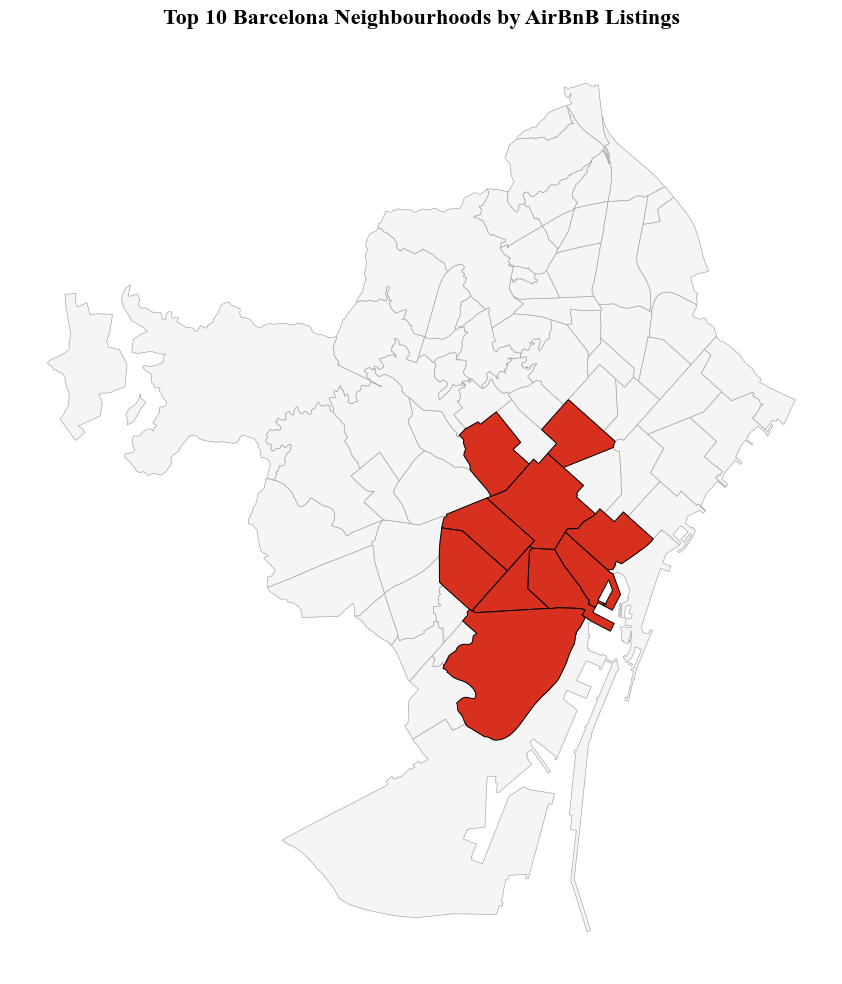

In [83]:
top_10_names = (
    airbnb_gdf["neighbourhood"]
    .value_counts()
    .head(10)
    .index
)

# Flag each neighbourhood polygon as top-10 or not
barcelona_map = barcelona_neighborhoods.to_crs(BAR_EPSG).copy()
barcelona_map["is_top_10"] = barcelona_map["neighbourhood"].isin(top_10_names)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Non-highlighted neighbourhoods in light grey
barcelona_map[~barcelona_map["is_top_10"]].plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="darkgrey",
    linewidth=0.5,
)

# Top 10 neighbourhoods highlighted
barcelona_map[barcelona_map["is_top_10"]].plot(
    ax=ax,
    color="#d7301f",
    edgecolor="black",
    linewidth=0.7,
)

ax.set_title("Top 10 Barcelona Neighbourhoods by AirBnB Listings")
ax.axis("off")
plt.tight_layout()
plt.show()

One of the articles cited initial in the background notes the general depopulation of the city center in recent history - the same area that's colored brightly red in the map above. One thing that I would have liked to do with more time and a perfect data set is model the population flow of long-term residents into different parts of the city to see what neighborhoods are gaining people leaving the city and how much the city center is depopulating relative to the rate of AirBnBs opening.

# Part 2: Modeling Largescale AirBnB Owners in Barcelona

The AirBnB dataset tracks the hosts of each residence using a unique host ID. The 18,177 properties in the city are owned by a total of 5,776 unique hosts, which equates to each host owning 3 properties on average. However, the traits of these hosts range greatly.

In [84]:
print ("Total number of properties:", len(airbnb_gdf))

print ("Total number of unique hosts:", airbnb_gdf["host_id"].nunique())

Total number of properties: 18177
Total number of unique hosts: 5776


In [85]:
desc = airbnb_gdf["calculated_host_listings_count"].describe()

label_map = {
    "count": "Count",
    "mean": "Mean",
    "std": "Std. Deviation",
    "min": "Minimum",
    "25%": "25th Percentile",
    "50%": "Median",
    "75%": "75th Percentile",
    "max": "Maximum",
}
desc_df = (
    desc.rename(index=label_map)
    .rename_axis("Statistic")
    .reset_index(name="Value")
)

styled = (
    desc_df.style
    .hide(axis="index")
    .format({"Value": "{:,.2f}"})
    .set_caption("Host Listings Summary Statistics")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("padding", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#4a4a4a"), ("color", "white"),
                   ("text-align", "left"), ("padding", "6px 12px")]},
        {"selector": "td",
         "props": [("padding", "6px 12px")]},
    ])
)
styled

Statistic,Value
Count,"18,177.00"
Mean,68.49
Std. Deviation,129.20
Minimum,1.00
25th Percentile,2.00
Median,9.00
75th Percentile,52.00
Maximum,549.00


As clearly evidenced by the large difference between the mean and median, a small number of AirBnB owners with a high amount of properties skew the ownership data to the right. 

Let's explore more about the hosts that are above the median of 9 properties when it comes to AirBnB ownership in the city. For the sake of convenience, we'll use the phrase "big landlords" for this group for the rest of the notebook.

In [86]:
big_landlords_gdf = airbnb_gdf.loc[airbnb_gdf["calculated_host_listings_count"] >= 9]

print ("The percentage of Barcelona AirBnB's owned by big landlords is ", len(big_landlords_gdf)/len(airbnb_gdf)*100, "%")

The percentage of Barcelona AirBnB's owned by big landlords is  50.993013148484344 %


## Part 3: la Dreta de l'Eixample Networking

In the original dataset, la Dreta de l'Eixample had almost double the number of AirBnBs inside its borders than the next most property-heavy. What does a basic look at the property ownership look-like? Also, how about we drop in some of the biggest tourist sites around the neighborhood? I used Google to search up the four most frequently visited sites in Dreta, then I added them in as points on the map!

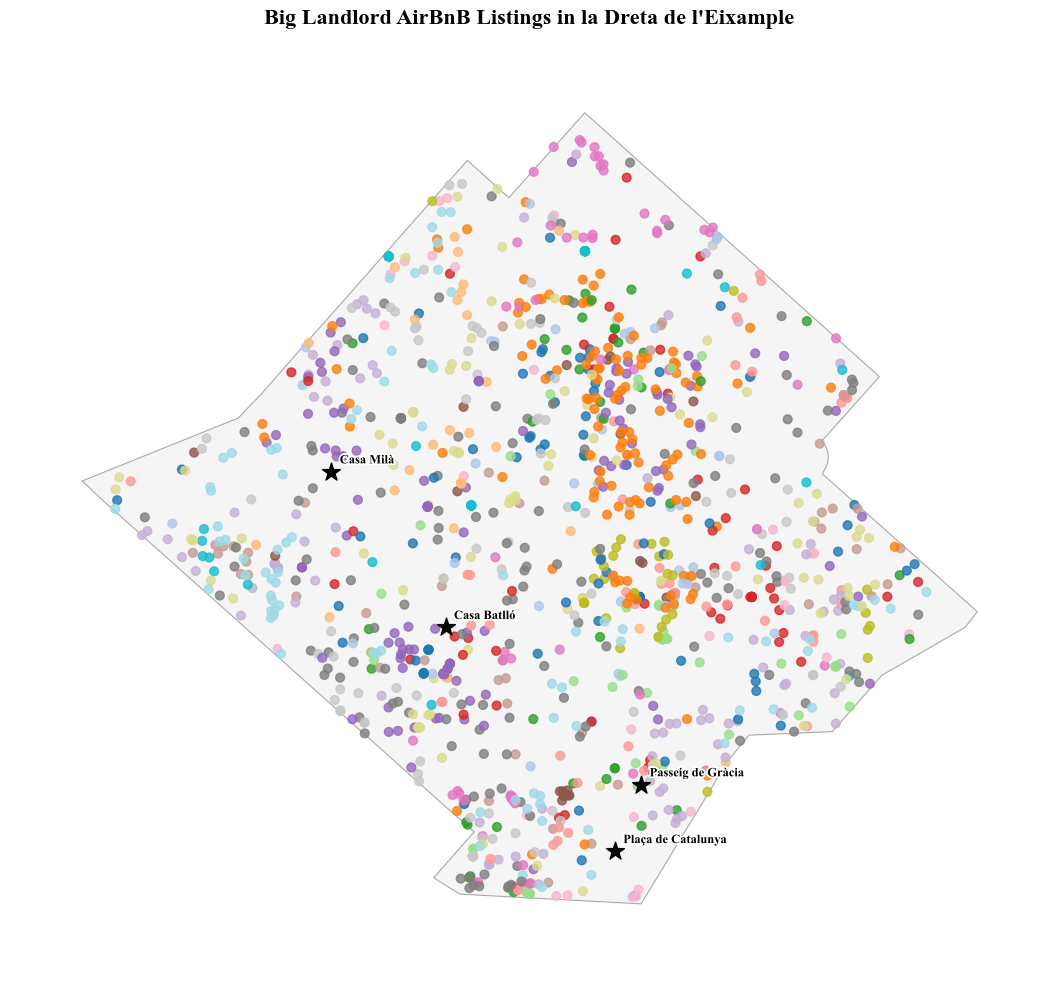

In [ ]:
dreta_gdf = big_landlords_gdf.loc[big_landlords_gdf["neighbourhood"] == "la Dreta de l'Eixample"]

#I turned this into a function to avoid repeating code for the next map
def dreta_map(df):
    
    # Join listings by host: one row per host, with a listing count
    dreta_hosts = (
        df
        .dissolve(by="host_id", aggfunc={"host_name": "first"})
        .reset_index()
    )
    dreta_hosts["listings_in_dreta"] = (
        df.groupby("host_id").size().values
    )

    #making a new map of just dreta
    dreta_poly = barcelona_map.loc[barcelona_map["neighbourhood"] == "la Dreta de l'Eixample"]

    fig, ax = plt.subplots(1, 1, figsize=(11, 10))

    dreta_poly.plot(ax=ax, color="whitesmoke",
                    edgecolor="darkgrey", linewidth=0.8)

    df.plot(
        ax=ax,
        column="host_id",
        categorical=True,
        cmap="tab20",
        markersize=40,
        alpha=0.8,
        legend=False,
    )


    #Because we're using a small snippet of the large map, I bring in the scale so it doesn't appear very tiny
    minx, miny, maxx, maxy = dreta_poly.total_bounds
    margin = 0.08 * max(maxx - minx, maxy - miny)

    # I used Google Maps to eyeball the coordinates
    landmarks = pd.DataFrame({
        "name": ["Casa Batlló", "Casa Milà",
                "Plaça de Catalunya", "Passeig de Gràcia"],
        "latitude":  [41.391700, 41.395216, 41.386630, 41.388041],
        "longitude": [2.164918,  2.161902,  2.169399,  2.170273],
    })

    # Project to the same CRS as the map
    landmarks_gdf = gpd.GeoDataFrame(
        landmarks,
        geometry=gpd.points_from_xy(landmarks["longitude"],
                                    landmarks["latitude"]),
        crs=4326,
    ).to_crs(BAR_EPSG)

    landmarks_gdf.plot(
        ax=ax,
        color="black",
        marker="*",
        markersize=180,
        zorder=5,
    )
    for _, row in landmarks_gdf.iterrows():
        ax.annotate(
            row["name"],
            xy=(row.geometry.x, row.geometry.y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            color="black",
            zorder=6,
            path_effects=[
                __import__("matplotlib.patheffects", fromlist=["withStroke"])
                .withStroke(linewidth=2.5, foreground="white")
            ],
        )
        
    ax.set_xlim(minx - margin, maxx + margin)
    ax.set_ylim(miny - margin, maxy + margin)

    ax.set_title(f"Big Landlord AirBnB Listings in la Dreta de l'Eixample")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

dreta_map(dreta_gdf)

138 hosts makes for a graph difficult to perceive. How about we limit it to just the super large hosts, who own 300 properties or more? 

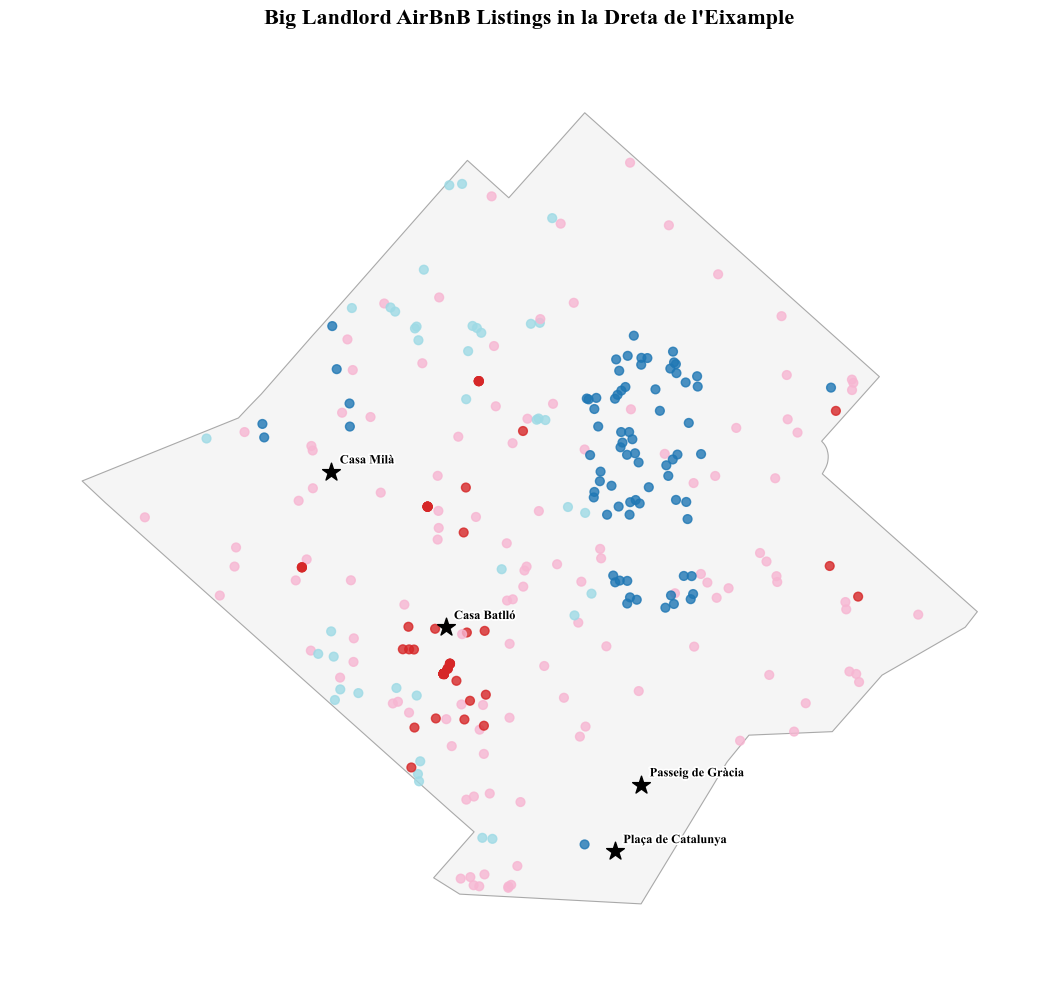

In [88]:
dreta_huge_gdf = big_landlords_gdf.loc[(big_landlords_gdf["neighbourhood"] == "la Dreta de l'Eixample") & (big_landlords_gdf["calculated_host_listings_count"] >= 300)]

dreta_map(dreta_huge_gdf)

The large blue clump above away from some of the major tourist sites intrigued me, and made me think that it was potentially a hub for shopping and markets. Originally, I thought more AirBnBs would be directly on the city center, but that wasn't true, and after doing searching, it makes more sense given that it's a huge plaza with several government buildings there.

## Part 4: Who is the biggest AirBnB owner in Barcelona? What does this network look like?

In [89]:
top_owner = airbnb_gdf.loc[airbnb_gdf["calculated_host_listings_count"] == airbnb_gdf["calculated_host_listings_count"].max()]

A host known as Ukio owns 524 different properties in the city of Barcelona. A cursory search finds their website, which is for short-term apartments advertised towards professionals, digital nomads, and students, among others [11]. Is this noticeable in the data?

In [90]:
print ("The average minimum stay time in a Barcelona AirBnB is ", airbnb_gdf["minimum_nights"].mean())

print ("The average minimum stay time in a Ukio unit is ", top_owner["minimum_nights"].mean())

The average minimum stay time in a Barcelona AirBnB is  16.592507014358805
The average minimum stay time in a Ukio unit is  31.120218579234972


The minimum stay time in the units owned by the largest property owner is double the average! That could mean that these units have a higher rate of occupancy than, say, a unit with a single night minimum.

The AirBnB data doesn't have the price of the unit nor its exact guest counts, but it does have a metric for the total number of reviews we could use as a surrogate for how busy the unit is and how many people have gone through it. About half of the units have 0 reviews, so in order to have them show up on the map, let's add one to each rows value for that column then adjust the legend on our maps.

Some research online lead me to discover the circlify package, which allows for clustering by bubble.

C:\Users\ganon\AppData\Local\Temp\ipykernel_6680\38790152.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(neighbourhoods))


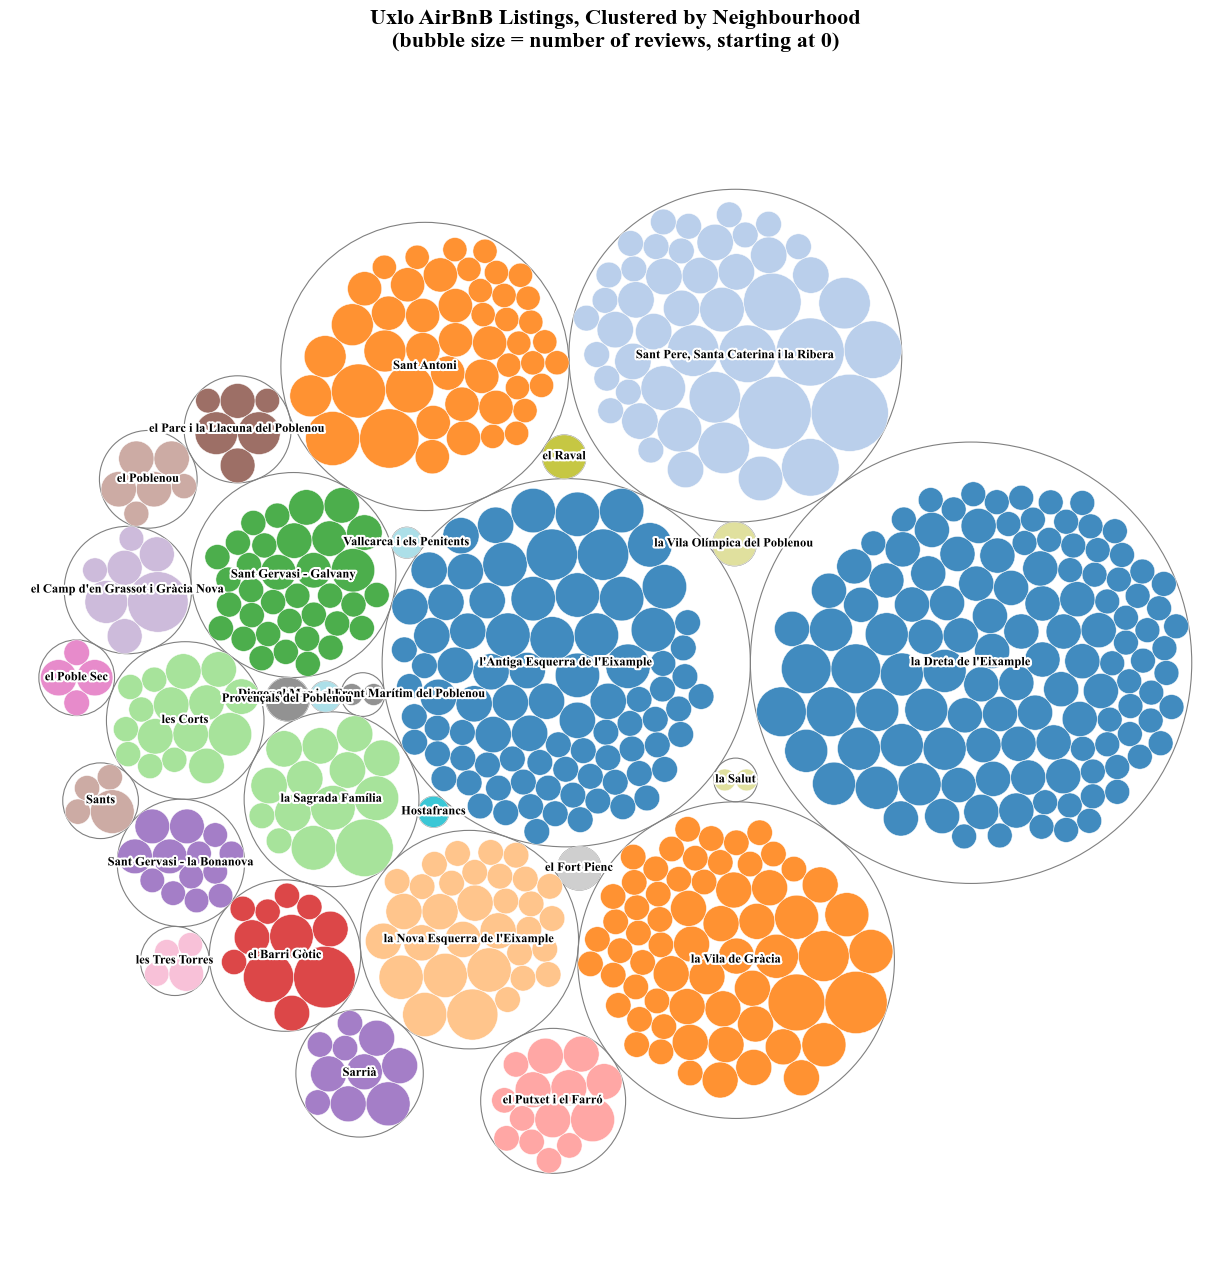

In [91]:
top_owner["number_of_reviews"] = top_owner["number_of_reviews"] + 1

# Look up tables keyed by listing id (always available on every child circle)
id_to_nbhd = dict(zip(top_owner["id"].astype(str),
                      top_owner["neighbourhood"]))
id_to_name = dict(zip(top_owner["id"].astype(str),
                      top_owner.get("name", top_owner["id"]).astype(str)))

# Build hierarchy: neighbourhood -> listings, leaf size = reviews (floored at 1)
data = []
for nbhd, grp in top_owner.groupby("neighbourhood"):
    children = [
        {"id": str(row["id"]),
         "datum": max(row["number_of_reviews"], 1)}
        for _, row in grp.iterrows()
    ]
    data.append({"id": nbhd,
                  "datum": sum(c["datum"] for c in children),
                  "children": children})

data.sort(key=lambda d: d["datum"], reverse=True)

circles = circlify.circlify(
    data,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1),
)

fig, ax = plt.subplots(figsize=(13, 13))
ax.set_aspect("equal")
ax.axis("off")

neighbourhoods = [d["id"] for d in data]
cmap = cm.get_cmap("tab20", len(neighbourhoods))
color_for = {n: cmap(i) for i, n in enumerate(neighbourhoods)}

#neighborhood outline
for circ in circles:
    if circ.level == 1:
        ax.add_patch(plt.Circle((circ.x, circ.y), circ.r,
                                facecolor="none",
                                edgecolor="grey", linewidth=0.8))
    elif circ.level == 2:
        # Listing bubble: look up its neighbourhood by id
        listing_id = circ.ex["id"]
        nbhd = id_to_nbhd.get(listing_id)
        ax.add_patch(plt.Circle((circ.x, circ.y), circ.r,
                                facecolor=color_for.get(nbhd, "grey"),
                                edgecolor="white", linewidth=0.4,
                                alpha=0.85))

#Drawing the cluster labels
for circ in circles:
    if circ.level == 1:
        ax.annotate(circ.ex["id"],
                    (circ.x, circ.y),
                    ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="black", zorder=10,
                    path_effects=[
                        __import__("matplotlib.patheffects",
                                   fromlist=["withStroke"])
                        .withStroke(linewidth=3, foreground="white")
                    ])

lim = max(abs(c.x) + c.r for c in circles) * 1.05
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_title("Uxlo AirBnB Listings, Clustered by Neighbourhood\n"
             "(bubble size = number of reviews, starting at 0)")
plt.tight_layout()
plt.show()

That large blue cluster from the previous examination of Dreta has been revealed!

Compared to the larger dataset, the smaller range for the value of reviews for Ukio's properties makes the size estimator actually a pretty bad estimator. If I had the true number of residents over the year, that would be a far more effective way to size the bubbles to show what I wanted to, which was an estimate for occupancy.

## Conclusion

Originally, I had a broad scope in mind to analyze Barcelona's entire economic reality - something that would have required much more data and comparisons. As this project developed, I'm glad I explored more of the cool dataset I had rather than try and branch out and include several other metrics. 

This notebook shows the spread of AirBnB units across Barcelona in the context of city center populations. Over half of these units are owned by individuals or companies that have 9 or more units. The original scope of this project thought to try and match property sales to the establishment of an AirBnB unit; that matching was beyond the scale of a microproject, but a more rigorous idea with complete data would be directly tracing what properties become go from permnanent housing to temporary rentals like an AirBnB.

My analysis was heavily inspired by the Mansueto Institute's [Who Owns Chicago project](https://whoownschi.miurban-dashboards.org/), which used mailing addresses for tax information to create a network of landlords and their property ownership across the city. One of the reasons this project emerged was because of conglomerates that used shell companies to hide the fact they owned hundreds of properties. I would be very interested in seeing the network of AirBnB hosts across the city and if there was some way to link hosts together, for instance, if one seemingly innoculous owner of 2-3 properties was affiliated with a private equity network. I have no clue how tax reporting works in Spain and where to start on this though. The process for the Chicago data has already taken two years to clean and polish and turn into a workable product, so this would be a massive endeavor.

At one point, I had the idea to potentially build a NetworkX graph to show all of the points connected to each other, but I couldn't quite figure out what the edges would mean. Who Owns Chicago uses one of these network graphs to show the connection between all of the shell companies and different landlords. As mentioned earlier, if I had this data, it would be really cool to examine the ownershup trends, but I ultimately didn't pursue this for the final product.

Citations:

[1] Harold Goodwin. "Managing Tourism in Barcelona." Responsible Tourism Partnership Working Paper No. 1. Published 10/2018. https://haroldgoodwin.info/RTPWP/012ManagingTourisminBarcelona.pdf

[2] Bianca Carrera Espiriu. "Overtourism: Barcelona Sparks Global Rethinking." Green European Journal. Published August 8, 2024. https://www.greeneuropeanjournal.eu/wp-content/uploads/pdf/overtourism-barcelona-sparks-global-rethinking.pdf

[3] "A Cost of Living Index for Spanish Cities." Banco de España. Analytical Articles, Economic Bulletin. Published 3/2021. https://www.bde.es/f/webbde/SES/Secciones/Publicaciones/InformesBoletinesRevistas/ArticulosAnaliticos/21/T3/Files/be2103-art29e.pdf

[4] Asunción Blanco-Romero, Macià Blázquez-Salom, Gemma Cànoves. "Barcelona, Housing Rent Bubble in a Tourist City. Social Responses and Local Policies." Sustainability, vol. 10, no. 6 (2018), article 2043. MDPI. Published June 15, 2018. https://www.mdpi.com/2071-1050/10/6/2043

[5] Miquel-Àngel Garcia-López, Jordi Jofre-Monseny, Rodrigo Martínez-Mazza, Mariona Segú. "Do short-term rental platforms affect housing markets? Evidence from Airbnb in Barcelona." Journal of Urban Economics, Volume 119, 2020, 103278, ISSN 0094-1190, https://doi.org/10.1016/j.jue.2020.103278

[6] Cristina Giner. "Barcelona's Tourist Headache as Residential Population Declines 11% Since 2015." Euronews, July 23, 2019. https://www.euronews.com/2019/07/23/barcelona-s-tourist-headache-as-residential-population-declines-11-since-2015

[7] Dennis Schüpf. "Barcelona: Planning Tools for Urban Green Justice." ArcGIS StoryMaps, Published May 29, 2022. https://storymaps.arcgis.com/stories/bda8850641684a40ae4199c449ee5a64

[8] Alexander Araya López. "A summer of phobias: media discourses on ‘radical’ acts of dissent against ‘mass tourism’ in Barcelona." Open Research Europe, Published June 10, 2021. https://pmc.ncbi.nlm.nih.gov/articles/PMC10445860/

[9] Joseph Wilson. "How the Humble Water Gun Became the Symbol of Barcelona's Anti-Tourism Movement." Associated Press, Published June 16, 2025. https://www.ap.org/news-highlights/spotlights/2025/how-the-humble-water-gun-became-the-symbol-of-barcelonas-anti-tourism-movement/

[10] "Barcelona Doubles Tourism Tax, One of the Highest in Europe, to Fund Housing." Reuters, Published February 25, 2026. https://www.reuters.com/business/barcelona-doubles-tourism-tax-one-highest-europe-fund-housing-2026-02-25/

[11] Ukio. "Barcelona Rental Apartments." https://landing.ukio.com/barcelona/rental-apartments


Data Sources:

Inside Airbnb. "Get the Data - Barcelona - Detailed Listings Data." Downloaded 5/18/2026. https://insideairbnb.com/get-the-data/

Inside Airbnb. "Get the Data - Barcelona - Neighborhoods." Downloaded 5/18/2026. https://insideairbnb.com/get-the-data/

Ajuntament de Barcelona Open Data Service. "Compravendes d'habitatges per tipologia d'ús (notaris)." Downloaded 5/18/2026. https://opendata-ajuntament.barcelona.cat/data/en/dataset/notaris_compravendes_trans_tip_us

Ajuntament de Barcelona Open Data Service. "Intensitat de l'activitat turística." Downloaded 5/18/2026. https://opendata-ajuntament.barcelona.cat/data/en/dataset/intensitat-activitat-turistica